# ch202 — Change and Motion

**Part VII: Calculus**

---

## 1. The Starting Point: Average Rate of Change

Before derivatives, there is a simpler question: how fast did something change *over an interval*?

If a car travels 120 km in 2 hours, its average speed is 60 km/h. This is the **average rate of change** of position with respect to time.

$$\text{average rate of change} = \frac{f(b) - f(a)}{b - a}$$

This is just the slope of the line connecting two points on the graph of f — the **secant line**.

Calculus asks: what happens when the interval shrinks to zero? The average rate becomes the **instantaneous rate**. That is the derivative.

*(This chapter builds the bridge. Derivatives arrive in ch205.)*

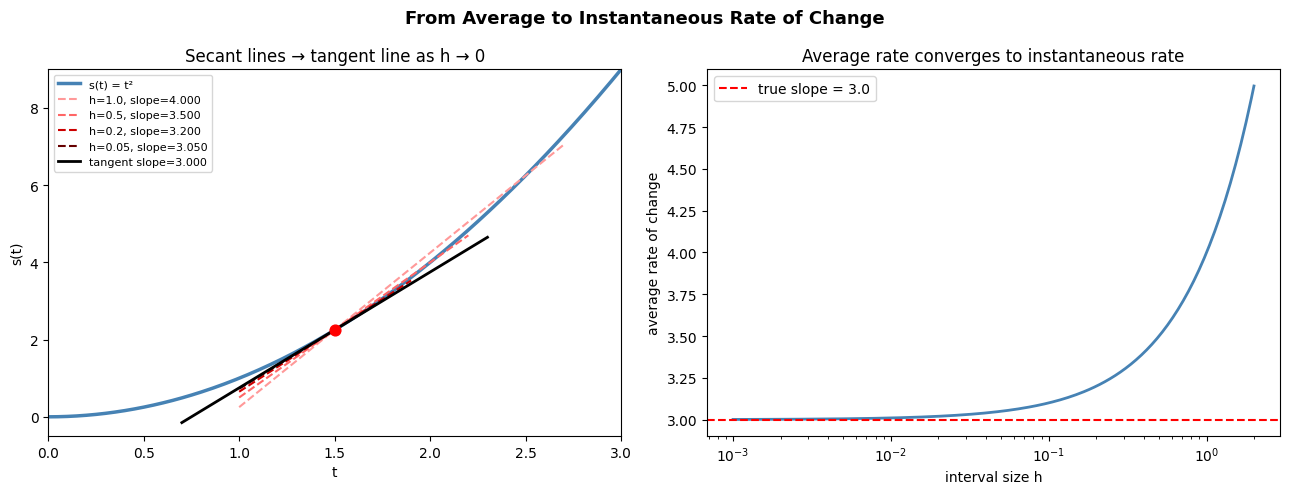

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Position function: s(t) = t^2  (imagine falling object, ignoring sign)
s = lambda t: t**2

t_vals = np.linspace(0, 3, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: secant lines shrinking toward tangent
t0 = 1.5
axes[0].plot(t_vals, s(t_vals), color='steelblue', linewidth=2.5, label='s(t) = t²')
axes[0].scatter([t0], [s(t0)], color='red', zorder=6, s=60)

colors = ['#ff9999', '#ff6666', '#cc0000', '#660000']
for h, color in zip([1.0, 0.5, 0.2, 0.05], colors):
    t1 = t0 + h
    slope = (s(t1) - s(t0)) / h
    x_line = np.array([t0 - 0.5, t1 + 0.2])
    y_line = s(t0) + slope * (x_line - t0)
    axes[0].plot(x_line, y_line, color=color, linewidth=1.5, linestyle='--',
                 label=f'h={h}, slope={slope:.3f}')

# True tangent: derivative of t^2 at t0 is 2*t0
true_slope = 2 * t0
x_tan = np.array([t0 - 0.8, t0 + 0.8])
y_tan = s(t0) + true_slope * (x_tan - t0)
axes[0].plot(x_tan, y_tan, color='black', linewidth=2, label=f'tangent slope={true_slope:.3f}')

axes[0].set_xlim(0, 3)
axes[0].set_ylim(-0.5, 9)
axes[0].set_title('Secant lines → tangent line as h → 0')
axes[0].set_xlabel('t')
axes[0].set_ylabel('s(t)')
axes[0].legend(fontsize=8)

# Right: average rate of change vs interval size
h_vals = np.logspace(-3, 0.3, 200)
avg_rates = [(s(t0 + h) - s(t0)) / h for h in h_vals]
axes[1].semilogx(h_vals, avg_rates, color='steelblue', linewidth=2)
axes[1].axhline(y=true_slope, color='red', linestyle='--', label=f'true slope = {true_slope}')
axes[1].set_xlabel('interval size h')
axes[1].set_ylabel('average rate of change')
axes[1].set_title('Average rate converges to instantaneous rate')
axes[1].legend()

plt.suptitle('From Average to Instantaneous Rate of Change', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Position, Velocity, Acceleration

The classic physical example is motion along a line:

- **Position** s(t): where the object is at time t
- **Velocity** v(t) = s'(t): how fast position changes
- **Acceleration** a(t) = v'(t) = s''(t): how fast velocity changes

Each is the derivative of the previous. This chain — position → velocity → acceleration — is the simplest example of repeated differentiation *(which reappears in ch217 — Second Derivatives)*.

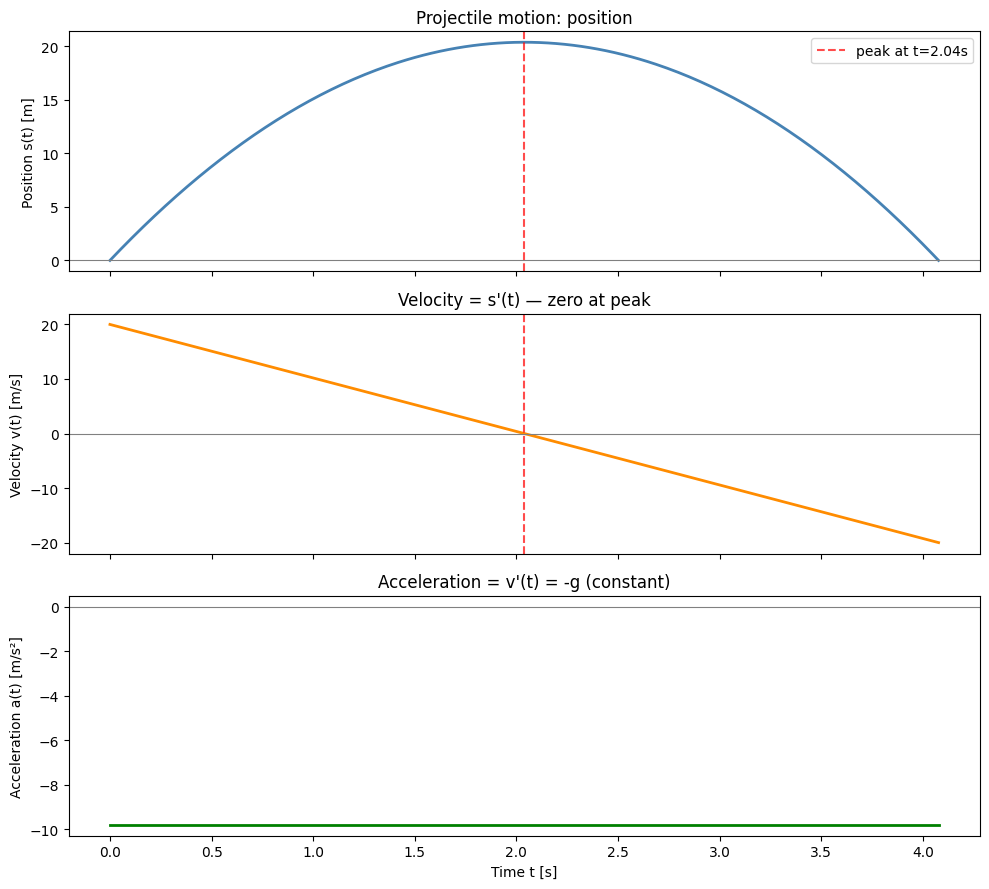

Peak height: 20.39 m at t = 2.04 s
Velocity at peak: 0.0000 m/s (≈ 0, as expected)
Acceleration is constant: -9.81 m/s² (gravity)


In [2]:
# Simulate a ball thrown upward: s(t) = v0*t - (1/2)*g*t^2
g = 9.81   # m/s^2
v0 = 20.0  # initial velocity m/s

s_fn  = lambda t: v0 * t - 0.5 * g * t**2          # position
v_fn  = lambda t: v0 - g * t                         # velocity (first derivative)
a_fn  = lambda t: -g * np.ones_like(t)               # acceleration (second derivative)

# Time until ball hits ground: s=0 => t=0 or t=2*v0/g
t_end = 2 * v0 / g
t = np.linspace(0, t_end, 300)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t, s_fn(t), color='steelblue', linewidth=2)
axes[0].set_ylabel('Position s(t) [m]')
axes[0].set_title('Projectile motion: position')
axes[0].axhline(0, color='gray', linewidth=0.8)
t_peak = v0 / g
axes[0].axvline(t_peak, color='red', linestyle='--', alpha=0.7, label=f'peak at t={t_peak:.2f}s')
axes[0].legend()

axes[1].plot(t, v_fn(t), color='darkorange', linewidth=2)
axes[1].set_ylabel('Velocity v(t) [m/s]')
axes[1].set_title("Velocity = s'(t) — zero at peak")
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].axvline(t_peak, color='red', linestyle='--', alpha=0.7)

axes[2].plot(t, a_fn(t), color='green', linewidth=2)
axes[2].set_ylabel('Acceleration a(t) [m/s²]')
axes[2].set_title("Acceleration = v'(t) = -g (constant)")
axes[2].set_xlabel('Time t [s]')
axes[2].axhline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f'Peak height: {s_fn(t_peak):.2f} m at t = {t_peak:.2f} s')
print(f'Velocity at peak: {v_fn(t_peak):.4f} m/s (≈ 0, as expected)')
print(f'Acceleration is constant: {a_fn(np.array([0.0]))[0]} m/s² (gravity)')

## 3. Numerical Average Rate of Change

You can compute average rates of change on discrete data — no calculus required. This is how NumPy's `np.diff` works.

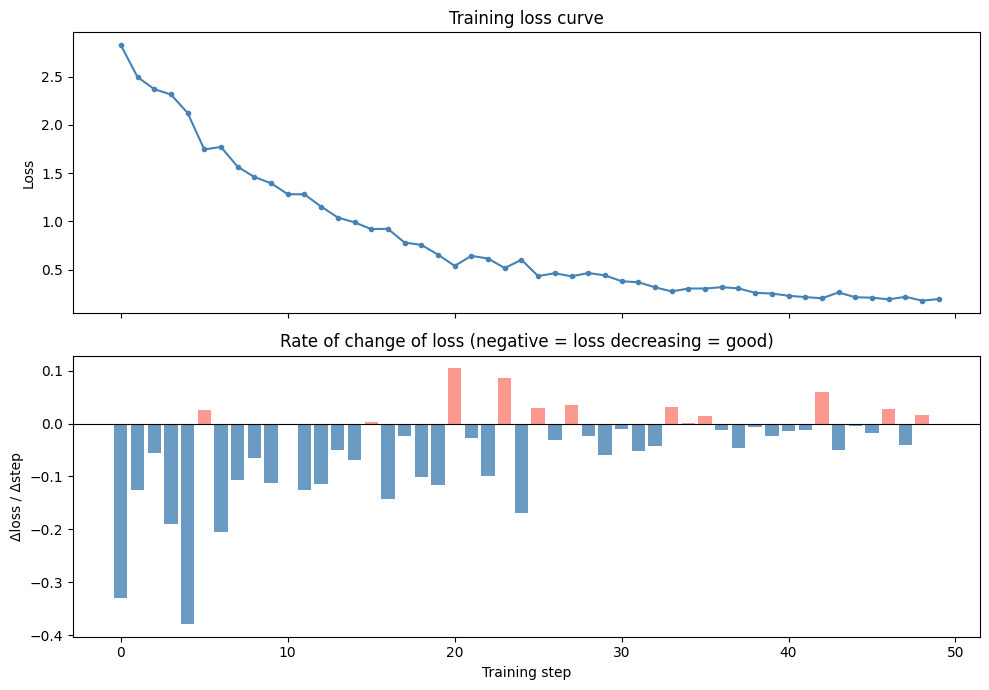

Average rate of change across all steps: -0.05367
This is: (final_loss - initial_loss) / total_steps = (0.197 - 2.826) / 49 = -0.05367


In [3]:
# Loss curve from a training run (simulated)
np.random.seed(0)
steps = np.arange(50)
loss = 2.5 * np.exp(-0.08 * steps) + 0.1 * np.random.randn(50) * np.exp(-0.04 * steps) + 0.15

# Average rate of change between consecutive steps
delta_loss = np.diff(loss)   # loss[i+1] - loss[i]
delta_step = 1               # steps are spaced 1 apart
rate = delta_loss / delta_step

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(steps, loss, 'o-', color='steelblue', markersize=3, linewidth=1.5)
axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss curve')

axes[1].bar(steps[:-1], rate, color=np.where(rate < 0, 'steelblue', 'salmon'), alpha=0.8, width=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Δloss / Δstep')
axes[1].set_xlabel('Training step')
axes[1].set_title('Rate of change of loss (negative = loss decreasing = good)')

plt.tight_layout()
plt.show()

print(f'Average rate of change across all steps: {np.mean(rate):.5f}')
print(f'This is: (final_loss - initial_loss) / total_steps = ({loss[-1]:.3f} - {loss[0]:.3f}) / 49 = {(loss[-1]-loss[0])/49:.5f}')

## 4. Key Vocabulary

| Term | Meaning |
|------|---------|
| **Secant line** | Line through two points on a curve — its slope is the average rate of change |
| **Tangent line** | Line touching the curve at one point — its slope is the instantaneous rate |
| **Difference quotient** | [f(x+h) - f(x)] / h — the secant slope formula |
| **Derivative** | Limit of the difference quotient as h → 0 |
| **Rate of change** | How much output changes per unit of input change |

---

## 5. Summary

- Average rate of change = slope of secant line = Δf / Δx
- As the interval shrinks, the secant approaches the tangent
- The instantaneous rate of change at a point is the derivative
- Position → velocity → acceleration is the chain of repeated differentiation
- On discrete data, `np.diff` gives the finite difference approximation to the derivative

---

## 6. Forward References

The difference quotient [f(x+h) - f(x)] / h is formalized as the limit definition of the derivative in ch203 — Limits Intuition and ch205 — Derivative Concept. The chain position → velocity → acceleration reappears in ch217 — Second Derivatives, and again in ch225 — Differential Equations where motion is defined by the equation s'' = -g.